# Unicorn Time to Scale

**Question:** what predicts how fast a company reaches a one billion dollar valuation, and does the apparent acceleration over time survive scrutiny?

This notebook works through the full analysis: cleaning the raw data, engineering features, exploring the data, testing whether the apparent speed-up in time to unicorn status is real or an artifact of how the data was collected, and modeling the result. Every cleaning and analysis decision is documented in a markdown cell as it is made, not retrofitted afterward.

## 1. First look

Before writing any cleaning logic, we look at the raw data as it actually is: shape, dtypes, and the first few rows. Even where issues like negative durations, an old outlier, or currency-formatted strings can be anticipated in advance, the point of this step is to verify that against the data itself rather than trust an assumption about it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/unicorn_companies.csv')
df.shape

(1074, 10)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Company           1074 non-null   str  
 1   Valuation         1074 non-null   str  
 2   Date Joined       1074 non-null   str  
 3   Industry          1074 non-null   str  
 4   City              1058 non-null   str  
 5   Country/Region    1074 non-null   str  
 6   Continent         1074 non-null   str  
 7   Year Founded      1074 non-null   int64
 8   Funding           1074 non-null   str  
 9   Select Investors  1073 non-null   str  
dtypes: int64(1), str(9)
memory usage: 84.0 KB


In [3]:
df.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [4]:
df.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Company'].duplicated().sum()

np.int64(1)

In [7]:
df[df['Company'].duplicated(keep=False)].sort_values('Company')

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
40,Bolt,$11B,5/29/18,Auto & transportation,Tallinn,Estonia,Europe,2013,$1B,"Didi Chuxing, Diamler, TMT Investments"
44,Bolt,$11B,10/8/21,Fintech,San Francisco,United States,North America,2014,$1B,"Activant Capital, Tribe Capital, General Atlantic"


## 2. Data Cleaning

Each decision below is made deliberately, documented with its rule and the row count it affects, not retrofitted after the fact. The raw file itself is never modified; cleaned output is kept separate.

### 2.1 Currency parsing

`Valuation` and `Funding` are strings like `"$11B"` or `"$500M"`. Before writing a parser, we check what suffixes actually appear in the data rather than assume the format is uniform across all 1,000+ rows.

In [8]:
df['Valuation'].str[-1].unique()

<StringArray>
['B']
Length: 1, dtype: str

In [9]:
df['Funding'].str[-1].unique()

<StringArray>
['B', 'M', 'n']
Length: 3, dtype: str

In [10]:
df[df['Funding'].str[-1] == 'n']['Funding'].unique()

<StringArray>
['Unknown']
Length: 1, dtype: str

In [11]:
df['Funding'].isna().sum()

np.int64(0)

In [12]:
def parse_currency(value):
    if value == 'Unknown' or value == "unknown":
        return np.nan

    numeric_part = value.replace('$', '')

    if numeric_part.endswith('B'):
        return float(numeric_part[:-1]) * 1e9
    elif numeric_part.endswith('M'):
        return float(numeric_part[:-1]) * 1e6

    return np.nan

df['valuation_numeric'] = df['Valuation'].apply(parse_currency)
df['funding_numeric'] = df['Funding'].apply(parse_currency)

### 2.2 Date parsing and the target variable

`Date Joined` is a string like `"5/29/18"`, using a two-digit year. Parsing it explicitly (rather than letting a library guess the century) lets us compute the actual target variable of this whole analysis: `years_to_unicorn`, the number of years between a company's founding and the date it reached unicorn status.

In [13]:
df[['Valuation', 'valuation_numeric']].head()

,Valuation,valuation_numeric
0,$180B,1.800000e+11
1,$100B,1.000000e+11
2,$100B,1.000000e+11
3,$95B,9.500000e+10
4,$46B,4.600000e+10


In [14]:
df[['Funding', 'funding_numeric']].sample(10)

,Funding,funding_numeric
640,$2B,2.000000e+09
356,$224M,2.240000e+08
1014,$1B,1.000000e+09
573,$507M,5.070000e+08
155,$2B,2.000000e+09
890,Unknown,NaN
715,$436M,4.360000e+08
841,$247M,2.470000e+08
474,$358M,3.580000e+08
415,$253M,2.530000e+08


In [15]:
df['funding_numeric'].isna().sum()

np.int64(12)

In [16]:
(df['Funding'] == 'Unknown').sum()

np.int64(12)

In [17]:
df['date_joined_parsed'] = pd.to_datetime(df['Date Joined'], format='%m/%d/%y')

In [18]:
df['date_joined_parsed'].dt.year.min(), df['date_joined_parsed'].dt.year.max()

(np.int32(2007), np.int32(2022))

In [19]:
df['years_to_unicorn'] = df['date_joined_parsed'].dt.year - df['Year Founded']

In [20]:
df['years_to_unicorn'].describe()

count    1074.000000
mean        7.000931
std         5.329672
min        -4.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        98.000000
Name: years_to_unicorn, dtype: float64

In [21]:
df[df['years_to_unicorn'] < 0][['Company', 'Date Joined', 'Year Founded', 'years_to_unicorn']]

,Company,Date Joined,Year Founded,years_to_unicorn
714,Yidian Zixun,10/17/17,2021,-4


### 2.3 Removing impossible negative durations

The summary statistics above immediately surface a problem: a negative minimum for `years_to_unicorn`, which is logically impossible, a company cannot reach unicorn status before it was founded.

In [22]:
df = df[df['years_to_unicorn'] >= 0].copy()
df.shape

(1073, 14)

### 2.4 Removing old-company outliers

The same summary statistics also showed an implausible maximum of 98 years. This is real data, not an error, but a genuinely old company revalued recently is a fundamentally different case than a fast-scaling modern startup, and including it would distort any regression built on this data.

In [23]:
df[df['Year Founded'] < 1990][['Company', 'Year Founded', 'Date Joined', 'years_to_unicorn']].sort_values('Year Founded')

,Company,Year Founded,Date Joined,years_to_unicorn
189,Otto Bock HealthCare,1919,6/24/17,98
373,Promasidor Holdings,1979,11/8/16,37
699,Five Star Business Finance,1984,3/26/21,37


In [24]:
df[df['Year Founded'] >= 1990]['Year Founded'].min()

np.int64(1990)

In [25]:
df = df[df['Year Founded'] >= 1990].copy()
df.shape

(1070, 14)

### 2.5 Country consolidation check

Real-world categorical data is often entered inconsistently, the same country written multiple ways would silently split what should be one group into several in any later aggregation. Before relying on `Country/Region` for anything, we check every unique value for variant spellings.

In [26]:
sorted(df['Country/Region'].unique())

['Argentina',
 'Australia',
 'Austria',
 'Bahamas',
 'Belgium',
 'Bermuda',
 'Brazil',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Croatia',
 'Czech Republic',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Hong Kong',
 'India',
 'Indonesia',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Lithuania',
 'Luxembourg',
 'Malaysia',
 'Mexico',
 'Netherlands',
 'Nigeria',
 'Norway',
 'Philippines',
 'Senegal',
 'Singapore',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Thailand',
 'Turkey',
 'United Arab Emirates',
 'United Kingdom',
 'United States',
 'Vietnam']

## 3. Feature Engineering

Each feature below encodes a specific hypothesis about what might predict speed to unicorn status, does when a company was founded matter, does the number of backers matter, does having a brand-name investor matter. `Valuation` and `Funding` are deliberately excluded from every feature built here: both are measured at or after the same moment as the outcome itself, using them to predict `years_to_unicorn` would be target leakage.

### 3.1 Investor features

Before parsing `Select Investors`, we check it for missing values, since a null needs a decision: does it mean zero investors, or information that was never recorded?

In [27]:

df[df['Select Investors'].isna()][['Company', 'Industry', 'Select Investors']]

,Company,Industry,Select Investors
629,LinkSure Network,Mobile & telecommunications,NaN


In [28]:
def count_investors(value):
    if pd.isna(value):
        return np.nan
    return len(value.split(','))

df['investor_count'] = df['Select Investors'].apply(count_investors)

In [29]:
df[['Select Investors', 'investor_count']].sample(8)

,Select Investors,investor_count
970,"Sequoia Capital China, SIG Asia Investments, Z...",3.0
526,"Cherry Ventures, Northzone Ventures, Global Fo...",3.0
1053,"Zeev Ventures, Bond, Fifth Wall Ventures",3.0
975,"Accel, Cobalt Capital, Andreessen Horowitz",3.0
109,Technology Crossover Ventures,1.0
533,"Accel, frst, Kima Ventures",3.0
906,"Delian Capital, China International Capital Co...",3.0
1017,"Atomico, NGP Capital, Google Ventures",3.0


In [30]:
df['investor_count'].isna().sum()

np.int64(1)

In [31]:
top_tier_investors = [
    'Sequoia', 'Andreessen Horowitz', 'Tiger Global', 'Accel',
    'SoftBank', 'Founders Fund', 'Insight Partners'
]

def has_top_tier(value):
    if pd.isna(value):
        return np.nan
    value_lower = value.lower()
    return any(investor.lower() in value_lower for investor in top_tier_investors)

df['has_top_tier_investor'] = df['Select Investors'].apply(has_top_tier)

In [32]:
df['has_top_tier_investor'].value_counts(dropna=False)

has_top_tier_investor
False    708
True     361
NaN        1
Name: count, dtype: int64

### 3.2 Founding cohort

`Year Founded` is banded into five-year cohorts. This is the most important feature in the whole analysis, it becomes the x-axis of the central truncation-bias chart later.

In [33]:
cohort_bins = [1989, 1999, 2004, 2009, 2014, 2021]
cohort_labels = ['pre-2000', '2000-2004', '2005-2009', '2010-2014', '2015+']

df['founding_cohort'] = pd.cut(df['Year Founded'], bins=cohort_bins, labels=cohort_labels)

In [34]:
df['founding_cohort'].value_counts(dropna=False).sort_index()

founding_cohort
pre-2000      23
2000-2004     40
2005-2009    114
2010-2014    413
2015+        480
Name: count, dtype: int64

### 3.3 Industry grouping

`Industry` has 16 raw categories, several with very few companies, and a duplicate hiding in the counts before it is even grouped.

In [35]:
df['Industry'].value_counts()

Industry
Fintech                                224
Internet software & services           205
E-commerce & direct-to-consumer        111
Artificial intelligence                 73
Health                                  73
Other                                   57
Supply chain, logistics, & delivery     57
Cybersecurity                           50
Data management & analytics             41
Mobile & telecommunications             37
Hardware                                34
Auto & transportation                   31
Edtech                                  28
Consumer & retail                       24
Travel                                  14
Artificial Intelligence                 11
Name: count, dtype: int64

In [36]:
df['Industry'] = df['Industry'].str.lower().str.capitalize()

In [37]:
df['Industry'].value_counts()

Industry
Fintech                                224
Internet software & services           205
E-commerce & direct-to-consumer        111
Artificial intelligence                 84
Health                                  73
Other                                   57
Supply chain, logistics, & delivery     57
Cybersecurity                           50
Data management & analytics             41
Mobile & telecommunications             37
Hardware                                34
Auto & transportation                   31
Edtech                                  28
Consumer & retail                       24
Travel                                  14
Name: count, dtype: int64

In [38]:
threshold = len(df) * 0.03
industry_counts = df['Industry'].value_counts()
small_industries = industry_counts[industry_counts < threshold].index.tolist()
small_industries

['Auto & transportation', 'Edtech', 'Consumer & retail', 'Travel']

In [39]:
df['industry_grouped'] = df['Industry'].apply(
    lambda x: 'Other' if x in small_industries else x
)

df['industry_grouped'].value_counts()

industry_grouped
Fintech                                224
Internet software & services           205
Other                                  154
E-commerce & direct-to-consumer        111
Artificial intelligence                 84
Health                                  73
Supply chain, logistics, & delivery     57
Cybersecurity                           50
Data management & analytics             41
Mobile & telecommunications             37
Hardware                                34
Name: count, dtype: int64

### 3.4 Continent grouping

`Country/Region` has 45 levels, several with only a handful of companies, too sparse to model directly. `Continent` is a natural, coarser geography feature, checked here for the same small-category instability before being used for modeling.

In [40]:
df['Continent'].value_counts(dropna=False)

Continent
North America    589
Asia             307
Europe           142
South America     21
Oceania            8
Africa             3
Name: count, dtype: int64

In [41]:
continent_threshold = len(df) * 0.03
continent_counts = df['Continent'].value_counts()
small_continents = continent_counts[continent_counts < continent_threshold].index.tolist()
small_continents

['South America', 'Oceania', 'Africa']

In [42]:
df['continent_grouped'] = df['Continent'].apply(
    lambda x: 'Other' if x in small_continents else x
)

df['continent_grouped'].value_counts()

continent_grouped
North America    589
Asia             307
Europe           142
Other             32
Name: count, dtype: int64

## 4. Exploratory Data Analysis

A shared chart style, kept deliberately simple: a single monochrome accent color, no chart borders on the top or right, direct annotation on the chart itself rather than a legend where practical. Most charts here are internal exploration; only the strongest, most decisive ones are carried further as polished, published figures.

In [43]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'font.size': 11,
})

ACCENT = '#2C3E50'

### 4.1 Distribution of years to unicorn

Understanding the target variable's shape, before anything else, informs whether a plain linear model is a reasonable starting point later.

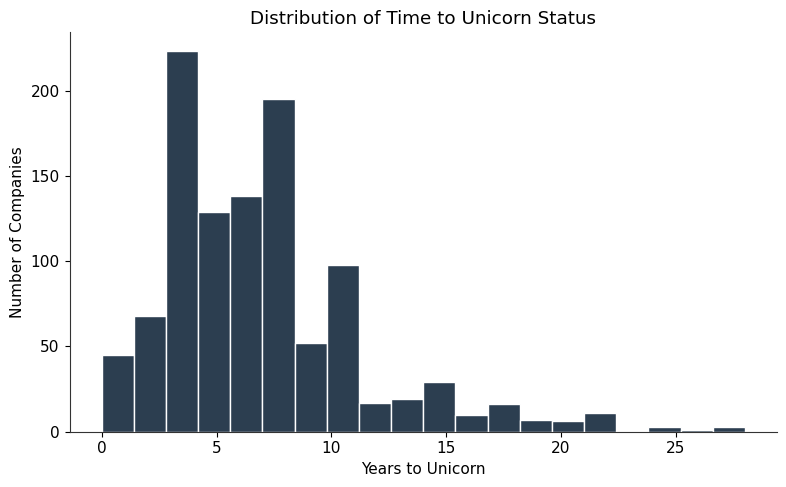

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['years_to_unicorn'], bins=20, color=ACCENT, edgecolor='white')
ax.set_xlabel('Years to Unicorn')
ax.set_ylabel('Number of Companies')
ax.set_title('Distribution of Time to Unicorn Status')
plt.tight_layout()
plt.show()

### 4.2 Distribution of valuation

`Valuation` is bounded below by definition, nothing here is under $1B, but has no upper bound, so a plain linear histogram is dominated by a handful of extreme values. Shown first on a linear scale, then a log scale, to see why the second is necessary. (`Valuation` itself is never used as a model feature, see the leakage note in section 3, this is descriptive only.)

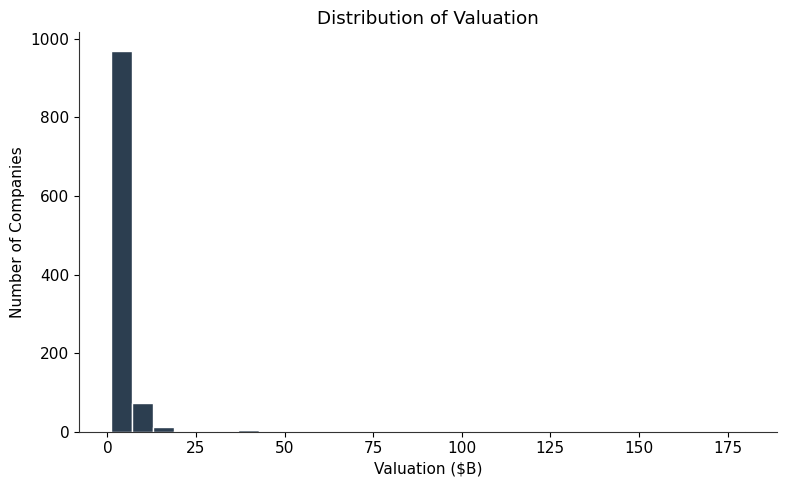

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['valuation_numeric'] / 1e9, bins=30, color=ACCENT, edgecolor='white')
ax.set_xlabel('Valuation ($B)')
ax.set_ylabel('Number of Companies')
ax.set_title('Distribution of Valuation')
plt.tight_layout()
plt.show()

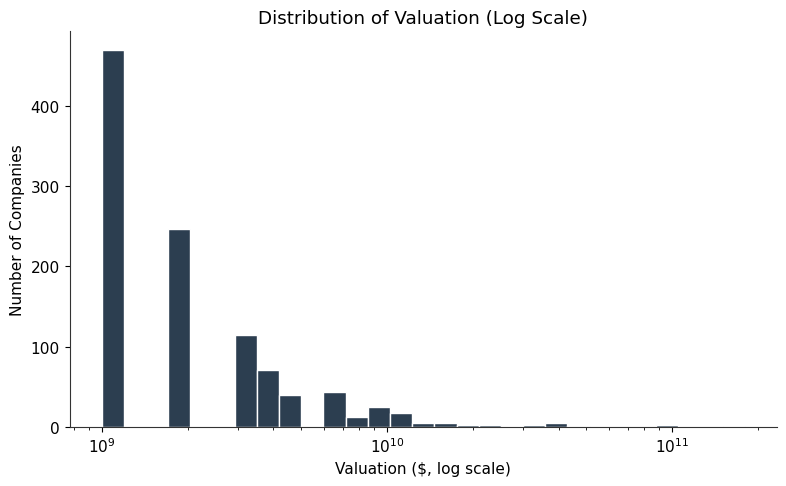

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.logspace(np.log10(df['valuation_numeric'].min()), np.log10(df['valuation_numeric'].max()), 30)
ax.hist(df['valuation_numeric'], bins=bins, color=ACCENT, edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Valuation ($, log scale)')
ax.set_ylabel('Number of Companies')
ax.set_title('Distribution of Valuation (Log Scale)')
plt.tight_layout()
plt.show()

### 4.3 Time to unicorn by industry

A boxplot to see the full distribution, not just a single average, of `years_to_unicorn` within each industry, and to check whether any industry shows genuine separation from the others.

Worth noting before reading the chart: every company in this dataset already reached unicorn status. A tighter spread for one industry does not mean that industry is more likely to succeed, it means the successful companies in that industry reached the milestone on a more consistent timeline. This dataset contains no information about companies that tried and did not succeed.

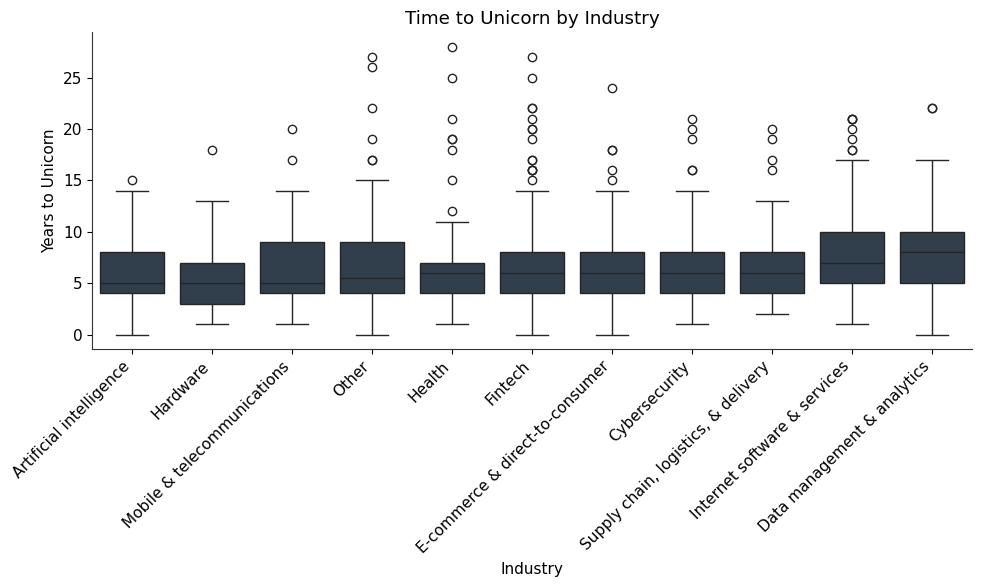

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
industry_order = df.groupby('industry_grouped')['years_to_unicorn'].median().sort_values().index
sns.boxplot(data=df, x='industry_grouped', y='years_to_unicorn', order=industry_order, color=ACCENT, ax=ax)
ax.set_xlabel('Industry')
ax.set_ylabel('Years to Unicorn')
ax.set_title('Time to Unicorn by Industry')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Truncation Bias: The Naive Result

This is the central question of the whole analysis: is the apparent acceleration in time to unicorn status real, or an artifact of how this dataset was collected? The naive result comes first, shown plainly and without softening, before any critique of it.

In [48]:
cohort_means = df.groupby('founding_cohort')['years_to_unicorn'].mean()
cohort_means

founding_cohort
pre-2000     21.391304
2000-2004    16.525000
2005-2009    11.473684
2010-2014     7.244552
2015+         3.954167
Name: years_to_unicorn, dtype: float64

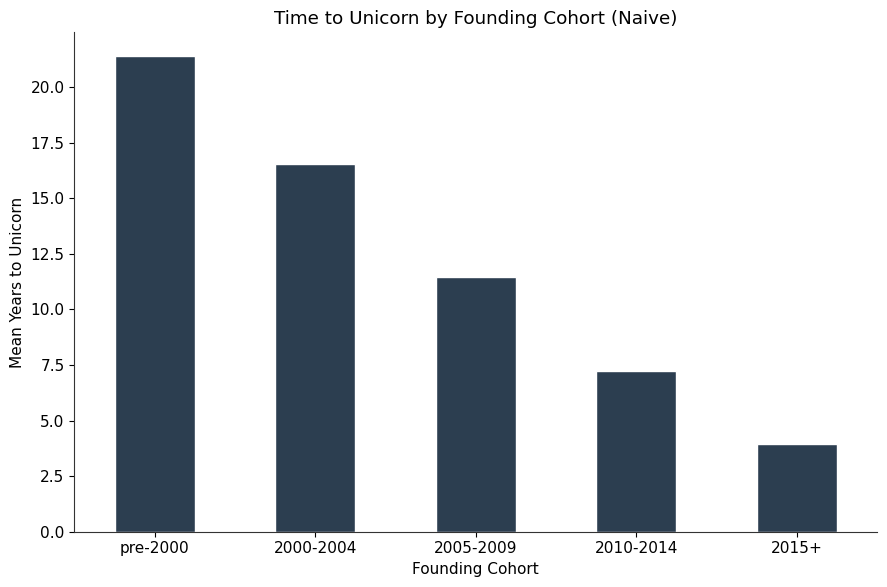

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))
cohort_means.plot(kind='bar', color=ACCENT, ax=ax, edgecolor='white')
ax.set_xlabel('Founding Cohort')
ax.set_ylabel('Mean Years to Unicorn')
ax.set_title('Time to Unicorn by Founding Cohort (Naive)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.1 When was this data collected?

A company can only appear in this dataset if it had already reached $1B by the time the data was collected. Checking the most recent `Date Joined` tells us that collection cutoff, since nothing here can have "joined" after that date.

In [50]:
df['date_joined_parsed'].max()

Timestamp('2022-04-05 00:00:00')

### 5.2 Why this might be misleading

The naive chart shows a sharp downward slope: `pre-2000` companies averaged **21.4 years** to reach unicorn status, while `2015+` companies averaged only **4.0 years**. At face value, this looks like unicorns are getting dramatically faster.

The dataset was collected shortly after the most recent `Date Joined`, April 5, 2022, so no company can appear here for having crossed the $1B line after that date. This creates **right-truncation**: survivorship bias within an incomplete observation window.

A company founded in 1995 has had about 27 years to cross the $1B threshold by 2022, enough time for essentially every unicorn from that cohort, fast or slow, to have already appeared. A company founded in 2020 has had at most 2 years, so only its fastest possible movers could have already qualified. Any 2020-founded company that will take 5, 8, or 10 years to scale is still invisible right now, not because it failed, but because it hasn't had time yet.

The consequence: the average `years_to_unicorn` computed for recent cohorts only reflects their fastest-scaling members, since the slower ones haven't shown up yet. This systematically pulls recent-cohort averages down, making it look like unicorns are getting dramatically faster, when some of that apparent acceleration is really just missing data on companies still in progress.

**Next: restrict to cohorts with a full, comparable observation window, and see how much of this trend survives.**

## 6. Correction: restrict to a fair observation window

There are two reasonable ways to correct for truncation bias: restrict the data to companies with a full, comparable observation window, or fit a model on the restricted data and compare its coefficients against the naive fit. Cohort restriction is used here rather than fitting and comparing two full models, it is simpler and easier to state plainly: "only companies that all had roughly the same amount of time to qualify are being compared." (The coefficient-comparison approach still gets used later, in section 9, as a second, independent check on this same finding.)

**Rule:** keep only companies founded on or before 2012. Since the dataset's collection cutoff is April 2022, this gives every remaining company roughly 10 years to have reached $1B.

**Limitation, stated honestly:** `Year Founded` is a whole year, not an exact date, so "founded 2012" could mean January 2012 (about 10 years 3 months by April 2022) or December 2012 (about 9 years 4 months). The rule gives *roughly* 10 years, not a guaranteed exact 10 for every row. This is a minor, second-order imprecision, a few months, on windows spanning a decade or more, and is not comparable in scale to the original truncation problem it is fixing, which was the difference between a 1-year window and a 27-year window.

In [ ]:
df_restricted = df[df['Year Founded'] <= 2012].copy()
df_restricted.shape

In [ ]:
restricted_means = df_restricted.groupby('founding_cohort')['years_to_unicorn'].mean()
restricted_means

## 7. What survives

| Cohort | Naive mean | Restricted mean |
|---|---|---|
| pre-2000 | 21.4 | 21.4 |
| 2000-2004 | 16.5 | 16.5 |
| 2005-2009 | 11.5 | 11.5 |
| 2010-2014 | 7.2 | **8.1** |
| 2015+ | 4.0 | **cannot be evaluated, no companies founded after 2012 have had a full window yet** |

Two things stand out.

First, the `2010-2014` mean rose from 7.2 to 8.1 once the still-partially-observed 2013-2014 companies were removed, leaving only the fully-observed 2010-2012 companies. This is a direct, concrete confirmation of the truncation mechanism itself: removing companies that have not had time to finish scaling raises the average, because it is disproportionately the fast movers who show up early, and it was exactly this effect inflating the naive `2010-2014` bar downward.

Second, and more importantly: **the naive chart's most dramatic data point, `2015+` averaging just 4.0 years, cannot be reproduced under a fair comparison at all.** No company founded after 2012 has had enough time yet to be judged on equal footing with the older cohorts, so that number should never have been presented as a real finding in the first place.

What does survive: a real downward trend across `pre-2000` through `2010-2014` (21.4 to 16.5 to 11.5 to 8.1), companies are still reaching unicorn status meaningfully faster than they did before 2000, even after correcting for the observation window. The acceleration is real, but it is smaller and slower than the naive chart implied, and the naive chart's sharpest-looking claim was substantially an artifact.

## 8. The flagship chart

One image showing the naive claim, the correction, and the visual proof together.

In [ ]:
comparison = pd.DataFrame({
    'naive': cohort_means,
    'restricted': restricted_means
})
comparison

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

x = np.arange(len(comparison))
width = 0.35
RESTRICTED_COLOR = '#A9B4C0'

naive_bars = ax.bar(x - width/2, comparison['naive'], width, color=ACCENT, edgecolor='white')
restricted_bars = ax.bar(x + width/2, comparison['restricted'].fillna(0), width, color=RESTRICTED_COLOR, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=0)
ax.set_ylabel('Mean Years to Unicorn')
ax.set_title('Time to Unicorn by Founding Cohort: Naive vs. Truncation-Corrected')
ax.set_ylim(0, 29)

for bar in naive_bars:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color=ACCENT)

for i, bar in enumerate(restricted_bars):
    if comparison['restricted'].isna().iloc[i]:
        continue
    h = bar.get_height()
    ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color='#5A6472')

ax.annotate('Naive\n(full dataset)', xy=(naive_bars[0].get_x() + naive_bars[0].get_width()/2, naive_bars[0].get_height()),
            xytext=(-45, 45), textcoords='offset points', ha='center', fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle='-', color=ACCENT, lw=0.8))

ax.annotate('Restricted\n(founded ≤ 2012)', xy=(restricted_bars[0].get_x() + restricted_bars[0].get_width()/2, restricted_bars[0].get_height()),
            xytext=(45, 45), textcoords='offset points', ha='center', fontsize=9, color='#5A6472',
            arrowprops=dict(arrowstyle='-', color='#5A6472', lw=0.8))

last = len(comparison) - 1
ax.annotate('No valid comparison,\nobservation window\nstill open', 
            xy=(x[last] + width/2, 0.3), xytext=(x[last] + width/2, 10),
            ha='center', fontsize=9, color='#8B3A3A',
            arrowprops=dict(arrowstyle='->', color='#8B3A3A'))

plt.tight_layout()
plt.savefig('reports/figures/naive_vs_corrected_cohort_chart.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Modeling

Three tiers, each run **twice**, once on the naive full dataset (`df`), once on the restricted dataset (`df_restricted`, founded ≤ 2012), because the comparison between them is itself a finding, an echo of the truncation story through model coefficients instead of group means.

1. **Baseline**: predict the median for everything. Every subsequent model has to beat this to be worth anything.
2. **Linear regression**: interpretable coefficients are the actual point here, not accuracy.
3. **Tree-based model** (Random Forest): for comparison and feature importance.

**Metrics:** MAE (mean absolute error) in years is the headline number, "the model is wrong by X years on average" is a sentence anyone can understand. RMSE is reported alongside it, it penalizes large errors more heavily since it squares differences before averaging. R² is secondary and expected to be modest, this is a genuinely hard prediction problem, and an honest, modest score is a stronger result than an inflated one built on leaky features.

**Features used:** `founding_cohort`, `industry_grouped`, `continent_grouped`, `investor_count`, `has_top_tier_investor`. **Excluded:** `valuation_numeric` and `funding_numeric`. Both are measured at or after the same moment as the outcome itself, using them to predict `years_to_unicorn` would be target leakage (see section 3).

### 9.1 Preparing features and a fair train/test split

Before fitting anything, the data needs to be split into a training portion (what the model learns from) and a test portion (held out, never seen during fitting), so evaluation is honest. Scoring a model on the same rows it was fit on inflates how good it looks, since it is just recalling what it already memorized rather than demonstrating it generalizes to new data.

One detail worth doing carefully: `founding_cohort` is very unevenly sized, 23 `pre-2000` companies versus 480 `2015+`. A plain random split could, by bad luck, put almost none of the tiny `pre-2000` group into the test set, making any evaluation involving that group noisy. The split below is **stratified** by `founding_cohort`, which forces each cohort's proportion to be preserved in both the training and test sets rather than left to chance.

In [ ]:
model_features = ['founding_cohort', 'industry_grouped', 'continent_grouped', 'investor_count', 'has_top_tier_investor']
target = 'years_to_unicorn'

df_model = df.dropna(subset=model_features + [target]).copy()
df_model.shape

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model[model_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_model['founding_cohort']
)
X_train.shape, X_test.shape

### 9.2 Baseline: predict the median

The simplest possible prediction: guess the same single number, the median `years_to_unicorn` from the training set, for every company in the test set, regardless of any of its features. If a real model cannot beat this, it is not adding any value.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_prediction = y_train.median()

y_pred_baseline = [baseline_prediction] * len(y_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = mean_squared_error(y_test, y_pred_baseline) ** 0.5

baseline_prediction, baseline_mae, baseline_rmse

Result: median prediction `6.0`, MAE `3.40`, RMSE `4.59`.

Same process on the restricted dataset, so there is a fair baseline to compare model performance against for both.

In [ ]:
df_restricted_model = df_restricted.dropna(subset=model_features + [target]).copy()
df_restricted_model.shape

In [ ]:
X_r = df_restricted_model[model_features]
y_r = df_restricted_model[target]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42, stratify=df_restricted_model['founding_cohort']
)
X_train_r.shape, X_test_r.shape

In [ ]:
baseline_prediction_r = y_train_r.median()

y_pred_baseline_r = [baseline_prediction_r] * len(y_test_r)

baseline_mae_r = mean_absolute_error(y_test_r, y_pred_baseline_r)
baseline_rmse_r = mean_squared_error(y_test_r, y_pred_baseline_r) ** 0.5

baseline_prediction_r, baseline_mae_r, baseline_rmse_r

**Baseline summary:**

| | Naive | Restricted |
|---|---|---|
| Median prediction | 6.0 | 10.0 |
| MAE | 3.40 | 3.44 |
| RMSE | 4.59 | 5.18 |

The restricted median (10.0) is well above the naive median (6.0), consistent with the truncation story: this data skews toward older companies that had a full, complete window, so a "typical" company here genuinely took longer. These are the numbers any real model has to beat.

### 9.3 Linear regression

Linear regression cannot multiply a coefficient by the text `"Fintech"`, it needs numbers. The fix is **one-hot encoding**: turn each category into its own 0/1 column, "is this row Fintech, yes or no."

Two details matter here, not just running the code:

- `drop_first=True` drops one category from each encoded column rather than keeping every one. If every category were kept, the columns would be perfectly redundant, you could figure out the last one just from knowing all the others were 0, which breaks linear regression's math (the "dummy variable trap"). The dropped category becomes the implicit baseline; every other coefficient is interpreted relative to it.
- Encoding train and test **separately** creates a real risk: some rare category could appear in one but not the other, producing mismatched columns. `reindex(columns=X_train_encoded.columns, fill_value=0)` forces the test set to line up exactly with the training set's columns, filling anything missing with 0.

In [ ]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train_encoded.shape, X_test_encoded.shape

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_encoded, y_train)

y_pred_linear = linear_model.predict(X_test_encoded)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = mean_squared_error(y_test, y_pred_linear) ** 0.5

linear_mae, linear_rmse

Strong result: MAE drops from 3.40 (baseline) to **1.87**, RMSE from 4.59 to **2.38**. A real, substantial beat, these features carry genuine predictive signal, this is not just noise.

Same process on the restricted dataset.

In [ ]:
X_train_r_encoded = pd.get_dummies(X_train_r, drop_first=True)
X_test_r_encoded = pd.get_dummies(X_test_r, drop_first=True)

X_test_r_encoded = X_test_r_encoded.reindex(columns=X_train_r_encoded.columns, fill_value=0)

linear_model_r = LinearRegression()
linear_model_r.fit(X_train_r_encoded, y_train_r)

y_pred_linear_r = linear_model_r.predict(X_test_r_encoded)

linear_mae_r = mean_absolute_error(y_test_r, y_pred_linear_r)
linear_rmse_r = mean_squared_error(y_test_r, y_pred_linear_r) ** 0.5

linear_mae_r, linear_rmse_r

Both linear models solidly beat their baselines (naive: 3.40 → 1.87 MAE; restricted: 3.44 → 2.16 MAE). The restricted model's slightly higher error makes sense too: it is working with a smaller sample (394 vs 1,070) and a more variable population, older companies span a much wider range of years than the naive data, which is dominated by fast, tightly-clustered recent companies.

### 9.4 Interpreting coefficients

This is the actual point of running a linear model here, not accuracy. Because `drop_first=True` was used, every categorical coefficient is relative to a dropped baseline category, not an absolute value. A `founding_cohort_2015+` coefficient of, say, -8 does not mean "2015+ companies take -8 years", it means "2015+ companies take 8 years *less* than whichever cohort got dropped as the baseline." The intercept represents the prediction for a company sitting in every baseline category at once, with `investor_count = 0`.

In [ ]:
coefficients = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'coefficient': linear_model.coef_
}).sort_values('coefficient')

coefficients

In [ ]:
linear_model.intercept_

**Naive model, reconstructed predictions per cohort** (intercept `20.4` + cohort coefficient, holding other features at baseline):

| Cohort | Coefficient | Predicted years |
|---|---|---|
| pre-2000 (baseline) | n/a | 20.4 |
| 2000-2004 | -5.26 | 15.1 |
| 2005-2009 | -10.34 | 10.0 |
| 2010-2014 | -14.71 | 5.7 |
| 2015+ | -17.89 | 2.5 |

**The trend is still fully there**, almost as dramatic as the raw group means, even after the model controls for industry, continent, investor count, and top-tier backing. Every other coefficient in the table is small, under 1 year; `founding_cohort` completely dominates the prediction.

This is an important, slightly uncomfortable finding: **controlling for more variables in a regression does not fix truncation bias.** That is not a modeling mistake, it is structural. Confounding variables (industry, geography, etc.) can be "controlled for" because they vary *within* the data already collected. Truncation is different: it is about entire rows that do not exist yet, and no predictor column can account for data that was never collected because it had not happened. This is exactly why the fix is cohort restriction, changing which rows are allowed into the analysis, not adding more features.

Now the same extraction on the restricted model, to see whether that same trend shrinks once the truncated rows are actually removed.

In [ ]:
coefficients_r = pd.DataFrame({
    'feature': X_train_r_encoded.columns,
    'coefficient': linear_model_r.coef_
}).sort_values('coefficient')

coefficients_r

In [ ]:
linear_model_r.intercept_

**`founding_cohort` coefficients, naive vs. restricted:**

| Cohort | Naive coefficient | Restricted coefficient |
|---|---|---|
| 2000-2004 | -5.26 | -4.23 |
| 2005-2009 | -10.34 | -9.11 |
| 2010-2014 | -14.71 | -12.70 |

(`founding_cohort_2015+` in the restricted model shows a coefficient of essentially `0` (`1.11e-15`). This is **not** a real finding, it is an artifact: `founding_cohort` is a pandas categorical column that still remembers `2015+` as a valid category even though zero rows in the restricted data belong to it, so that entire dummy column is all zeros and teaches the model nothing. Do not quote this number.)

**Every real coefficient shrank once restricted to a fair observation window**, not just the most extreme cohort this time. This is a second, independent confirmation of the same story, this time from regression coefficients instead of group means, the same "compare coefficients before and after restriction" idea introduced as an alternative correction method in section 6. Both approaches point the same way.

### 9.5 Tree-based model: Random Forest

A Random Forest is an ensemble of many decision trees, each trained on a randomly resampled subset of the training rows and considering only a random subset of features at each split. The final prediction is just the average across every tree in the forest. This randomness, combined with averaging (called "bagging"), is what keeps a forest from overfitting the way a single, deep decision tree easily would.

Why add this on top of linear regression: a tree-based model can capture non-linear relationships and interactions, for example, having a top-tier investor might matter more in some industries than others, that a plain linear model cannot represent at all. It also gives a different, complementary way to ask "what matters": **feature importance**, which, unlike our one-hot linear coefficients, is not relative to an arbitrarily dropped baseline category, making it more directly comparable across features.

We reuse the same one-hot encoded feature matrices from the linear regression step, this keeps the comparison between model types fair, both are seeing exactly the same information.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5

rf_mae, rf_rmse

Result: MAE `1.87`, RMSE `2.55`, essentially tied with linear regression on MAE, slightly worse on RMSE. Same process on the restricted dataset.

In [ ]:
rf_model_r = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_r.fit(X_train_r_encoded, y_train_r)

y_pred_rf_r = rf_model_r.predict(X_test_r_encoded)

rf_mae_r = mean_absolute_error(y_test_r, y_pred_rf_r)
rf_rmse_r = mean_squared_error(y_test_r, y_pred_rf_r) ** 0.5

rf_mae_r, rf_rmse_r

Result: MAE `1.94`, RMSE `2.76`. The restricted Random Forest actually edges out the restricted linear model on MAE (1.94 vs 2.16), while RMSE is nearly identical between them. Neither model type dominates the other, both substantially beat their baselines, and the sizes of the gaps are modest, consistent with this being a genuinely hard prediction problem.

### 9.6 Feature importance

Unlike linear regression's coefficients, a Random Forest's feature importances are not relative to a dropped baseline category, they measure how much each feature actually reduced prediction error across every split in every tree, and are directly comparable to one another.

In [ ]:
importances = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importances

In [ ]:
importances_r = pd.DataFrame({
    'feature': X_train_r_encoded.columns,
    'importance': rf_model_r.feature_importances_
}).sort_values('importance', ascending=False)

importances_r

**Naive model, top feature importances:**

| Feature | Importance |
|---|---|
| `founding_cohort_2015+` | 0.41 |
| `founding_cohort_2010-2014` | 0.31 |
| `founding_cohort_2005-2009` | 0.11 |
| `founding_cohort_2000-2004` | 0.02 |
| everything else combined | 0.15 |

`founding_cohort` alone accounts for roughly 85% of the naive model's total importance. This is a **third independent confirmation** of the same finding, this time from a completely different technique, tree-based feature importance, not group means or linear coefficients: the truncation artifact dominates the naive model's predictions almost entirely, dwarfing industry, geography, and investor signal combined.

**Restricted model, top feature importances:**

| Feature | Importance |
|---|---|
| `founding_cohort_2010-2014` | 0.46 |
| `founding_cohort_2005-2009` | 0.24 |
| `investor_count` | 0.04 |
| `continent_grouped_North America` | 0.03 |
| `founding_cohort_2000-2004` | 0.03 |
| `founding_cohort_2015+` | 0.00 |

Same artifact as before: `founding_cohort_2015+` has exactly zero importance in the restricted model. A tree can never split on a column that is entirely zeros, there is nothing to learn from a feature with no variation. This confirms, through a third method now, that the naive `2015+` figure cannot be validated under a fair comparison.

### 9.7 Model comparison summary

| Model | Naive MAE | Naive RMSE | Naive R² | Restricted MAE | Restricted RMSE | Restricted R² |
|---|---|---|---|---|---|---|
| Baseline | 3.40 | 4.59 | -0.03 | 3.44 | 5.18 | -0.04 |
| Linear regression | 1.87 | 2.38 | 0.72 | 2.16 | 2.79 | 0.70 |
| Random Forest | 1.87 | 2.55 | 0.68 | 1.94 | 2.76 | 0.70 |

Both real models comfortably beat the baseline on both datasets, and neither model type is a clear winner over the other, they land within a few hundredths of a year of each other on MAE. An R² around 0.7 means the models explain a meaningful share of the variation in `years_to_unicorn`, roughly 70%, but leave real, honest uncertainty unexplained. That is expected and stated plainly rather than hidden: time to unicorn status depends on countless factors this dataset does not capture (product execution, market timing, competitive dynamics), and a model that explained nearly all of it would be a sign of leakage, not skill.

**The headline modeling finding:** three separate techniques, naive group means, linear regression coefficients, and Random Forest feature importance, all independently identify `founding_cohort` as the dominant signal in the naive dataset, and all three show that signal weakening once the data is restricted to a fair observation window. The truncation bias is not a quirk of one particular method, it shows up no matter how the data is analyzed, and correcting for it is not optional.